In [ ]:
# ONLY RUN THIS IF YOU'RE IN GOOGLE COLAB
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Thesis/Pintu-Air/notebooks')

# Verify you're in the right place
!pwd
!ls -la

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from scipy.stats import boxcox, boxcox_normmax, boxcox_llf, chi2
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults
from statsmodels.stats.diagnostic import acorr_ljungbox, lilliefors
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import warnings
import gc
import os
import time
import ast
warnings.filterwarnings('ignore')

# Functions Needed

In [2]:
def plot_acf_pacf(data, period, lag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 12))

    # ACF Plot
    for lag in range(period, lag+1, period):
        axes[0].axvline(x=lag, color='red', linestyle='--', linewidth=1, zorder=0)
    plot_acf(data, ax=axes[0], lags=lag, marker='o', markersize=3)
    axes[0].set_title('Autocorrelation Function (ACF)')

    # PACF Plot
    for lag in range(period, lag+1, period):
        axes[1].axvline(x=lag, color='red', linestyle='--', linewidth=1, zorder=0)
    plot_pacf(data, ax=axes[1], lags=lag, marker='o', markersize=3)
    axes[1].set_title('Partial Autocorrelation Function (PACF)')

    plt.tight_layout()
    plt.show()

def boxcox_transformation(data):
    lambda_opt = boxcox_normmax(data, method='mle').item()

    # Log-likelihood with optimum lambda
    llf_opt = boxcox_llf(lambda_opt, data)

    # Log-likelihood if lambda = 1
    llf_null = boxcox_llf(1.0, data)

    # Calculate LRT
    lrt_stat = (2 * (llf_opt - llf_null)).item()

    # Calculate p-value (df = 1)
    p_value = chi2.sf(lrt_stat, df=1)

    print(f"Lambda optimal: {lambda_opt:.8f}")
    print(f"LRT statistic: {lrt_stat:.8f}")
    print(f"P-value: {p_value:.6f}")

    return lambda_opt

def inverse_transform(transformed_data, lambda_opt):
    if lambda_opt == 0:
        return np.exp(transformed_data)  # Log case: e^(transformed_data)
    elif lambda_opt == 1:
        return transformed_data  # No transformation case
    else:
        return np.power(transformed_data, 1/lambda_opt)

def modelling(order, data_y_train_trans, data_y_train, data_y_test, seasonal_order=None, exog=False, data_x_train=None, data_x_test=None, lambda_opt=1.0):
    # Generate model name automatically
    if seasonal_order is None:
        model_name = f"ARIMA{order}"
        if exog:
            model_name = f"ARIMAX{order}"
    else:
        model_name = f"SARIMA{order}x{seasonal_order}"
        if exog:
            model_name = f"SARIMAX{order}x{seasonal_order}"

    print(f"\n{'='*60}")
    print(f"Testing {model_name}")
    print(f"{'='*60}")

    # Start timing
    start_time = time.time()

    try:
        # Create model based on parameters
        if seasonal_order is None:
            # ARIMA or ARIMAX
            if exog and data_x_train is not None:
                model = SARIMAX(data_y_train_trans, exog=data_x_train, order=order)
            else:
                model = ARIMA(data_y_train_trans, order=order)
        else:
            # SARIMA or SARIMAX
            if exog and data_x_train is not None:
                model = SARIMAX(data_y_train_trans, exog=data_x_train,
                              order=order, seasonal_order=seasonal_order)
            else:
                model = SARIMAX(data_y_train_trans, order=order, seasonal_order=seasonal_order)

        # Fit the model
        print("Fitting model...")
        if seasonal_order is None and not exog:
            results = model.fit()
        else:
            results = model.fit(disp=False)

        print("Model fitted successfully!")
        print(results.summary())

        # Calculate training time
        training_time = time.time() - start_time

        # Get residuals for diagnostic tests
        residuals = results.resid

        # Ljung-Box Test (test for white noise)
        ljung_box_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
        ljung_box_pvalue = ljung_box_result['lb_pvalue'].iloc[0]
        print(f"\nLjung-Box Test:\n{ljung_box_result}")

        # Lilliefors Test (test for normality)
        stat, lillie_pvalue = lilliefors(residuals)
        print(f"Lilliefors Test: statistic={stat:.8f}, p-value={lillie_pvalue:.8f}")

        # Check if all variables are significant
        pvalues = results.pvalues
        all_significant = all(pvalues < 0.05)

        print("Calculating training metrics...")

        fitted_values = results.fittedvalues  # These are in transformed space
        fitted_values_transformed = inverse_transform(fitted_values, lambda_opt)

        # Calculate all training metrics
        rmse_train = np.sqrt(mean_squared_error(data_y_train, fitted_values_transformed))
        mae_train = mean_absolute_error(data_y_train, fitted_values_transformed)
        r2_train = r2_score(data_y_train, fitted_values_transformed)
        mape_train = mean_absolute_percentage_error(data_y_train, fitted_values_transformed)

        print(f"Training RMSE: {rmse_train:.8f}")
        print(f"Training MAE: {mae_train:.8f}")
        print(f"Training R²: {r2_train:.8f}")
        print(f"Training MAPE: {mape_train:.8f}%")

        print("Calculating testing metrics...")

        # Your original calculation (which was correct!)
        if exog and data_x_test is not None:
            forecast = results.forecast(steps=len(data_y_test), exog=data_x_test)
        else:
            forecast = results.forecast(steps=len(data_y_test))

        forecast_transformed = inverse_transform(forecast, lambda_opt)

        # Calculate all testing metrics
        rmse_test = np.sqrt(mean_squared_error(data_y_test, forecast_transformed))
        mae_test = mean_absolute_error(data_y_test, forecast_transformed)
        r2_test = r2_score(data_y_test, forecast_transformed)
        mape_test = mean_absolute_percentage_error(data_y_test, forecast_transformed) * 100

        print(f"Testing RMSE: {rmse_test:.8f}")
        print(f"Testing MAE: {mae_test:.8f}")
        print(f"Testing R²: {r2_test:.8f}")
        print(f"Testing MAPE: {mape_test:.8f}%")

        # Print diagnostic test results
        print(f"\nDiagnostic Tests:")
        print(f"Ljung-Box p-value: {ljung_box_pvalue:.6f} ({'White Noise' if ljung_box_pvalue > 0.05 else 'Not White Noise'})")
        print(f"Lilliefors p-value: {lillie_pvalue:.6f} ({'Normal Distribution' if lillie_pvalue > 0.05 else 'Not Normal'})")
        print(f"All variables significant: {'Yes' if all_significant else 'No'}")

        # Create results dictionary with all metrics (matching XGBoost/LSTM format)
        results_dict = {
            'Model': model_name,
            'Semua Variabel Signifikan': 'Ya' if all_significant else 'Tidak',
            'P-value Ljung Box': f"{ljung_box_pvalue:.6f}",
            'White Noise?': 'Ya' if ljung_box_pvalue > 0.05 else 'Tidak',
            'P-value Lillie Test': f"{lillie_pvalue:.6f}",
            'Distribusi Normal?': 'Ya' if lillie_pvalue > 0.05 else 'Tidak',
            'Training Time (s)': f"{training_time:.8f}",
            'RMSE Training': f"{rmse_train:.8f}",
            'RMSE Testing': f"{rmse_test:.8f}",
            'MAE Training': f"{mae_train:.8f}",
            'MAE Testing': f"{mae_test:.8f}",
            'MAPE Training': f"{mape_train:.8f}",
            'MAPE Testing': f"{mape_test:.8f}",
            'R² Training': f"{r2_train:.8f}",
            'R² Testing': f"{r2_test:.8f}",
        }

        print(f"\nModel {model_name} completed successfully!")

        # Memory cleanup
        del model, results, fitted_values, fitted_values_transformed, forecast, forecast_transformed, residuals

    except Exception as e:
        print(f"Error fitting {model_name}: {str(e)}")
        training_time = time.time() - start_time

        # Create error results dictionary
        results_dict = {
            'Model': model_name,
            'Semua Variabel Signifikan': 'Error',
            'P-value Ljung Box': 'Error',
            'White Noise?': 'Error',
            'P-value Lillie Test': 'Error',
            'Distribusi Normal?': 'Error',
            'Training Time (s)': f"{training_time:.8f}",
            'RMSE Training': 'Error',
            'RMSE Testing': 'Error',
            'MAE Training': 'Error',
            'MAE Testing': 'Error',
            'MAPE Training': 'Error',
            'MAPE Testing': 'Error',
            'R² Training': 'Error',
            'R² Testing': 'Error'
        }

    csv_file = '22_arima_results.csv'

    try:
        # Read existing results if file exists
        if os.path.exists(csv_file):
            existing_df = pd.read_csv(csv_file)
            # Add new result
            new_df = pd.concat([existing_df, pd.DataFrame([results_dict])], ignore_index=True)
        else:
            # Create new dataframe
            new_df = pd.DataFrame([results_dict])

        # Save back to CSV
        new_df.to_csv(csv_file, index=False)
        print(f"Results saved to {csv_file}")

    except Exception as save_error:
        print(f"Error saving to CSV: {save_error}")

# Import Data

In [3]:
y_train = pd.read_csv('04_y_train.csv', index_col='Tanggal')
y_test = pd.read_csv('04_y_test.csv', index_col='Tanggal')

print(y_train.head())
print(y_test.head())

                     manggarai_air
Tanggal                           
2021-10-17 00:00:00          590.0
2021-10-17 01:00:00          575.0
2021-10-17 02:00:00          570.0
2021-10-17 03:00:00          565.0
2021-10-17 04:00:00          560.0
                     manggarai_air
Tanggal                           
2025-09-01 12:00:00          670.0
2025-09-01 13:00:00          670.0
2025-09-01 14:00:00          670.0
2025-09-01 15:00:00          670.0
2025-09-01 16:00:00          650.0


# Uji Stasioneritas

## Uji Stasioneritas terhadap Varians

$$
\begin{aligned}
H_0&: \lambda=1 \text{(Stasioner terhadap varians)}\\H_1&: \lambda\ne1\\
\end{aligned}
$$

In [4]:
lambda_opt = round(boxcox_transformation(y_train),1)

Lambda optimal: 1.52515404
LRT statistic: 727.76653664
P-value: 0.000000


In [5]:
print(f"{lambda_opt}")

1.5


Karena P-Value LR test lambda(1) = 0.000000 < 0.05, maka tolak H0, maka data tidak stasioner terhadap varians, sehingga perlu dilakukan transformasi sesuai dengan lambda optimal

In [6]:
y_train_pow = y_train ** lambda_opt
boxcox_transformation(y_train_pow)

Lambda optimal: 1.01676938
LRT statistic: 1.21640729
P-value: 0.270067


1.016769383090372

## Uji Stasioneritas terhadap Mean

$$
\begin{aligned}
H_0&: \text{Data tidak stasioner terhadap mean}\\
H_1&: \text{Data stasioner terhadap mean}\\
\end{aligned}
$$

In [7]:
result = adfuller(y_train_pow)

# Hasil ADF test
print(f"ADF Statistic : {result[0]}")
print(f"p-value       : {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key} : {value}")

ADF Statistic : -9.962449054999741
p-value       : 2.354016474432768e-17
Critical Values:
   1% : -3.4305427607757
   5% : -2.86162519541463
   10% : -2.566815346856351


In [8]:
y_train_pow.head()

,manggarai_air
Tanggal,
2021-10-17 00:00:00,14331.050206
2021-10-17 01:00:00,13788.015630
2021-10-17 02:00:00,13608.563480
2021-10-17 03:00:00,13429.896686
2021-10-17 04:00:00,13252.018714


## Uji Stasioneritas terhadap Mean

$$
\begin{aligned}
H_0&: \text{Data tidak stasioner terhadap mean}\\
H_1&: \text{Data stasioner terhadap mean}\\
\end{aligned}
$$

In [9]:
y_train_seasonal_diff = y_train_pow.diff(24).dropna()
result = adfuller(y_train_seasonal_diff)

# Hasil ADF test
print(f"ADF Statistic : {result[0]}")
print(f"p-value       : {result[1]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key} : {value}")

ADF Statistic : -28.82728201212327
p-value       : 0.0
Critical Values:
   1% : -3.4305429427734007
   5% : -2.8616252758504217
   10% : -2.5668153896702637


Karena p-value 1.225e-14 =  < 0.05, maka tolak H0, sehingga kita memiliki cukup bukti untuk menyimpulkan bahwa data stasioner terhadap mean

# ACF PACF

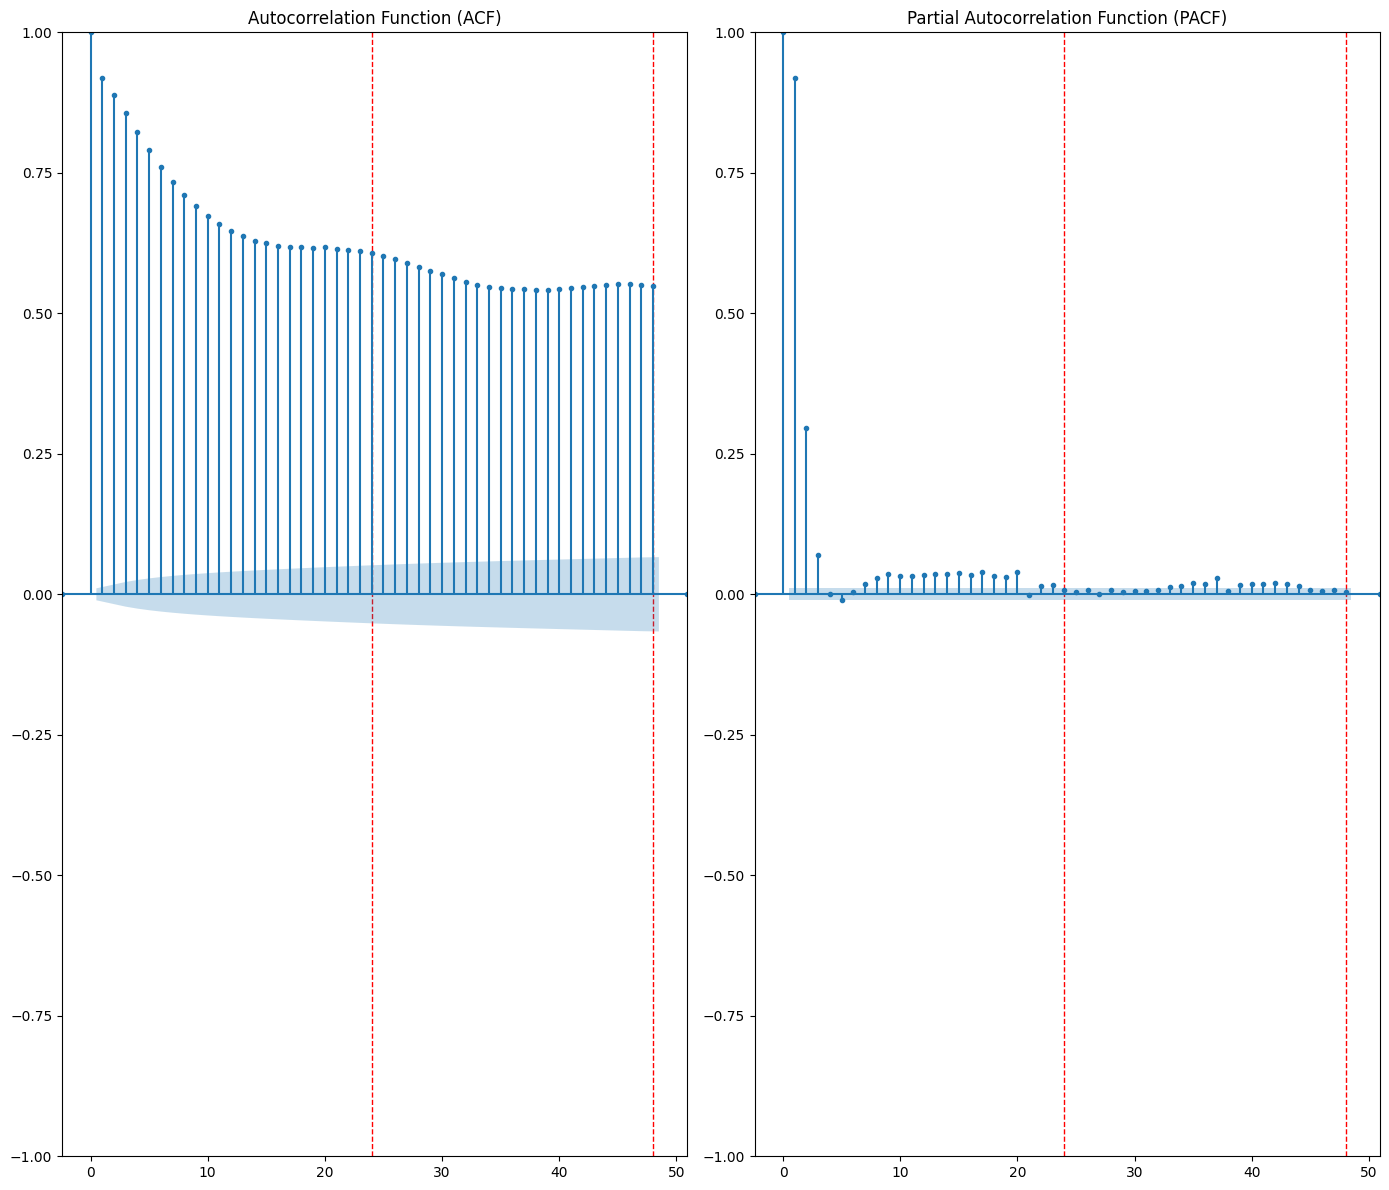

In [9]:
plot_acf_pacf(y_train_pow, 24, 48)

# Modelling ARIMA & SARIMA

In [10]:
# AR Model based on PACF
for p in range(1,24):
    order = (p,0,0)
    modelling(
        order=order,
        exog=False,
        data_y_train_trans=y_train_pow,
        data_y_train=y_train,
        data_y_test=y_test,
        lambda_opt=lambda_opt
    )


Testing ARIMA(1, 0, 0)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                33972
Model:                 ARIMA(1, 0, 0)   Log Likelihood             -268447.157
Date:                Fri, 26 Dec 2025   AIC                         536900.313
Time:                        12:33:06   BIC                         536925.613
Sample:                    10-17-2021   HQIC                        536908.383
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.583e+04     62.962    251.466      0.000    1.57e+04     1.6e+04
ar.L1          0.9180      0.001   1130.310      0.000       0.

KeyboardInterrupt: 

In [11]:
# MA model
for q in range(1,32):
    order = (0,0,q)
    modelling(
        order=order,
        exog=False,
        data_y_train_trans=y_train_pow,
        data_y_train=y_train,
        data_y_test=y_test,
        lambda_opt=lambda_opt
    )


Testing ARIMA(0, 0, 1)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                33972
Model:                 ARIMA(0, 0, 1)   Log Likelihood             -286721.737
Date:                Fri, 26 Dec 2025   AIC                         573449.473
Time:                        09:21:50   BIC                         573474.773
Sample:                    10-17-2021   HQIC                        573457.543
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.583e+04     10.422   1519.237      0.000    1.58e+04    1.59e+04
ma.L1          0.7020      0.001    668.626      0.000       0.

In [ ]:
# ARMA and SARMA model
for p in range (1, 5):
    for q in range(1,16):
        for season in [None, (1,0,0,24), (0,0,1,24), (1,0,1,24)]:
            order = (p,0,q)
            modelling(
                order=order,
                exog=False,
                data_y_train_trans=y_train_pow,
                data_y_train=y_train,
                data_y_test=y_test,
                seasonal_order=season,
                lambda_opt=lambda_opt
            )

Streaming output truncated to the last 5000 lines.
ar.L3          0.8442      0.046     18.443      0.000       0.755       0.934
ma.L1          0.9539      0.041     23.142      0.000       0.873       1.035
ma.L2          0.3355      0.040      8.339      0.000       0.257       0.414
ma.L3         -0.3445      0.018    -19.147      0.000      -0.380      -0.309
ma.L4         -0.0708      0.006    -10.920      0.000      -0.083      -0.058
ma.L5         -0.1304      0.008    -16.563      0.000      -0.146      -0.115
ma.L6         -0.1600      0.008    -19.168      0.000      -0.176      -0.144
ma.L7         -0.1891      0.009    -20.006      0.000      -0.208      -0.171
ma.L8         -0.1601      0.007    -22.731      0.000      -0.174      -0.146
ma.L9         -0.0812      0.005    -15.347      0.000      -0.092      -0.071
ar.S.L24       0.9973      0.001   1213.940      0.000       0.996       0.999
ma.S.L24      -0.9926      0.001   -666.619      0.000      -0.996      -0.990
s

In [10]:
# ARMA and SARMA model
for q in range(14,16):
    for season in [None, (1,0,0,24), (0,0,1,24), (1,0,1,24)]:
        order = (4,0,q)
        modelling(
            order=order,
            exog=False,
            data_y_train_trans=y_train_pow,
            data_y_train=y_train,
            data_y_test=y_test,
            seasonal_order=season,
            lambda_opt=lambda_opt
        )


Testing ARIMA(4, 0, 14)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                33972
Model:                ARIMA(4, 0, 14)   Log Likelihood             -266484.517
Date:                Sat, 27 Dec 2025   AIC                         533009.035
Time:                        01:59:24   BIC                         533177.701
Sample:                    10-17-2021   HQIC                        533062.835
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.583e+04    243.705     64.967      0.000    1.54e+04    1.63e+04
ar.L1          0.4671      0.460      1.015      0.310      -0

# Modelling ARIMAX & SARIMAX

In [10]:
X_train = pd.read_csv('05_X_train_binary.csv', index_col='Tanggal')
X_test = pd.read_csv('05_X_test_binary.csv', index_col='Tanggal')

print(X_train.head())
print(X_test.head())

                     time_index  hour_sin  hour_cos  dayofweek_sin  \
Tanggal                                                              
2021-10-17 00:00:00          24  0.000000  1.000000      -0.781831   
2021-10-17 01:00:00          25  0.258819  0.965926      -0.781831   
2021-10-17 02:00:00          26  0.500000  0.866025      -0.781831   
2021-10-17 03:00:00          27  0.707107  0.707107      -0.781831   
2021-10-17 04:00:00          28  0.866025  0.500000      -0.781831   

                     dayofweek_cos  dayofyear_sin  dayofyear_cos  \
Tanggal                                                            
2021-10-17 00:00:00        0.62349      -0.962068       0.272811   
2021-10-17 01:00:00        0.62349      -0.962068       0.272811   
2021-10-17 02:00:00        0.62349      -0.962068       0.272811   
2021-10-17 03:00:00        0.62349      -0.962068       0.272811   
2021-10-17 04:00:00        0.62349      -0.962068       0.272811   

                     manggarai_a

In [11]:
exog_columns = [
    'manggarai_cuaca_lag1_hujan', 'depok_air_lag8', 'depok_cuaca_lag8_hujan', 'katulampa_air_lag14', 'katulampa_cuaca_lag14_hujan'
]

X_train = X_train[exog_columns]
X_test = X_test[exog_columns]

print(X_train.head())
print(X_test.head())

                     manggarai_cuaca_lag1_hujan  depok_air_lag8  \
Tanggal                                                           
2021-10-17 00:00:00                           0            80.0   
2021-10-17 01:00:00                           0            80.0   
2021-10-17 02:00:00                           0            80.0   
2021-10-17 03:00:00                           0            80.0   
2021-10-17 04:00:00                           0            80.0   

                     depok_cuaca_lag8_hujan  katulampa_air_lag14  \
Tanggal                                                            
2021-10-17 00:00:00                       0                 10.0   
2021-10-17 01:00:00                       0                 10.0   
2021-10-17 02:00:00                       0                 10.0   
2021-10-17 03:00:00                       0                 10.0   
2021-10-17 04:00:00                       0                 10.0   

                     katulampa_cuaca_lag14_hujan  
Ta

In [12]:
def string_to_tuple(string_tuple):
    if pd.isna(string_tuple) or string_tuple == '':
        return None
    try:
        return ast.literal_eval(string_tuple.strip())
    except:
        return None

In [13]:
compare = pd.read_csv('22_arima_results.csv')
compare.tail(10)

,Model,Semua Variabel Signifikan,P-value Ljung Box,White Noise?,P-value Lillie Test,Distribusi Normal?,Training Time (s),RMSE Training,RMSE Testing,MAE Training,MAE Testing,MAPE Training,MAPE Testing,R² Training,R² Testing
356,"ARIMAX(1, 0, 11)",Tidak,0.010350,Tidak,0.001000,Tidak,269.815029,25.69235771,33.42706937,11.63589973,27.10481774,0.02693935,4.49207692,0.66452421,-2.59266911
357,"SARIMAX(1, 0, 11)x(1, 0, 1, 24)",Tidak,0.008184,Tidak,0.001000,Tidak,2061.323833,29.09743223,43.21981364,14.17021060,32.29785789,0.03085082,5.25522506,0.56970868,-5.00601475
358,"ARIMAX(1, 0, 12)",Tidak,0.034252,Tidak,0.001000,Tidak,330.268909,25.94220977,37.03537622,11.73483695,31.87364955,0.02709465,5.22412674,0.65796764,-3.41015786
359,"SARIMAX(1, 0, 12)x(1, 0, 1, 24)",Error,Error,Error,Error,Error,1368.662310,Error,Error,Error,Error,Error,Error,Error,Error
360,"ARIMAX(1, 0, 13)",Tidak,0.941873,Ya,0.001000,Tidak,342.193060,24.50257230,42.22310838,11.31208695,32.12648345,0.02651911,5.20209755,0.69487583,-4.73219582
361,"SARIMAX(1, 0, 13)x(1, 0, 0, 24)",Tidak,0.939611,Ya,0.001000,Tidak,665.027268,24.50472500,46.33691845,11.31049041,36.39667301,0.02651511,5.85004930,0.69482221,-5.90358873
362,"SARIMAX(1, 0, 13)x(1, 0, 1, 24)",Tidak,0.000000,Tidak,0.001000,Tidak,1377.337158,24.44587193,183.97596674,11.19974881,165.55790068,0.02627705,25.45320089,0.69628634,-107.82853969
363,"ARIMAX(1, 0, 14)",Tidak,0.345258,Ya,0.001000,Tidak,394.137125,24.46241868,40.88167479,11.23962553,30.62082168,0.02641112,4.97370279,0.69587505,-4.37375636
364,"SARIMAX(1, 0, 14)x(1, 0, 0, 24)",Tidak,0.274794,Ya,0.001000,Tidak,698.015697,24.48548035,42.26682846,11.44867681,32.06808392,0.02672196,5.19308696,0.69530136,-4.74407282
365,"SARIMAX(1, 0, 14)x(1, 0, 1, 24)",Tidak,0.000000,Tidak,0.001000,Tidak,2425.460602,24.73579385,28.25895847,11.84480196,17.56812943,0.02742981,2.99223400,0.68903969,-1.56763281


In [23]:
# Load the CSV file
df_models = pd.read_csv('23_arima_results_all_significant.csv')
df_models

,Order,Seasonal Order
0,"(1, 0, 0)",NaN
1,"(2, 0, 0)",NaN
2,"(3, 0, 0)",NaN
3,"(0, 0, 1)",NaN
4,"(0, 0, 2)",NaN
...,...,...
117,"(4, 0, 10)","(1, 0, 0, 24)"
118,"(4, 0, 11)","(1, 0, 0, 24)"
119,"(4, 0, 12)","(1, 0, 0, 24)"
120,"(4, 0, 14)","(1, 0, 0, 24)"


In [ ]:
# Single loop for all models with exogenous variables only
for i, row in df_models.iterrows():
    normal_order = string_to_tuple(row['Order'])
    seasonal_order = string_to_tuple(row['Seasonal Order'])

    if normal_order:
        modelling(
            order=normal_order,
            seasonal_order=seasonal_order,
            exog=True,
            data_y_train_trans=y_train_pow,
            data_y_train=y_train,
            data_y_test=y_test,
            data_x_train=X_train,
            data_x_test=X_test,
            lambda_opt=lambda_opt
        )


Testing ARIMAX(1, 0, 0)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                33972
Model:               SARIMAX(1, 0, 0)   Log Likelihood             -268862.020
Date:                Sat, 27 Dec 2025   AIC                         537738.039
Time:                        17:11:49   BIC                         537797.072
Sample:                    10-17-2021   HQIC                        537756.869
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
manggarai_cuaca_lag1_hujan    205.1229     13.946     14.708      0.000     177.789     232.457
depok_air_l

In [15]:
# Load the CSV file
df_models = pd.read_csv('23_arima_results_all_significant.csv')
df_models = df_models[67:]
df_models

,Order,Seasonal Order
67,"(1, 0, 15)",NaN
68,"(1, 0, 15)","(1, 0, 0, 24)"
69,"(1, 0, 15)","(1, 0, 1, 24)"
70,"(2, 0, 1)",NaN
71,"(2, 0, 1)","(1, 0, 0, 24)"
72,"(2, 0, 1)","(0, 0, 1, 24)"
73,"(2, 0, 1)","(1, 0, 1, 24)"
74,"(2, 0, 2)",NaN
75,"(2, 0, 3)","(0, 0, 1, 24)"
76,"(2, 0, 3)","(1, 0, 1, 24)"


In [16]:
# Single loop for all models with exogenous variables only
for i, row in df_models.iterrows():
    normal_order = string_to_tuple(row['Order'])
    seasonal_order = string_to_tuple(row['Seasonal Order'])

    if normal_order:
        modelling(
            order=normal_order,
            seasonal_order=seasonal_order,
            exog=True,
            data_y_train_trans=y_train_pow,
            data_y_train=y_train,
            data_y_test=y_test,
            data_x_train=X_train,
            data_x_test=X_test,
            lambda_opt=lambda_opt
        )


Testing ARIMAX(1, 0, 15)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                33972
Model:              SARIMAX(1, 0, 15)   Log Likelihood             -286438.878
Date:                Sun, 28 Dec 2025   AIC                         572921.755
Time:                        05:29:51   BIC                         573107.288
Sample:                    10-17-2021   HQIC                        572980.935
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
manggarai_cuaca_lag1_hujan    706.4852     67.501     10.466      0.000     574.186     838.785
depok_air_

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
# Single loop for all models with exogenous variables only
for i, row in df_models.iterrows():
    normal_order = string_to_tuple(row['Order'])
    seasonal_order = string_to_tuple(row['Seasonal Order'])

    if normal_order:
        modelling(
            order=normal_order,
            seasonal_order=seasonal_order,
            exog=True,
            data_y_train_trans=y_train_pow,
            data_y_train=y_train,
            data_y_test=y_test,
            data_x_train=X_train,
            data_x_test=X_test,
            lambda_opt=lambda_opt
        )


Testing ARIMAX(1, 0, 1)
Fitting model...
Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:          manggarai_air   No. Observations:                29640
Model:               SARIMAX(1, 0, 1)   Log Likelihood             -214383.687
Date:                Wed, 18 Jun 2025   AIC                         428787.375
Time:                        02:07:10   BIC                         428870.343
Sample:                    10-17-2021   HQIC                        428814.011
                         - 03-04-2025                                         
Covariance Type:                  opg                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
depok_air_lag8                -1.3710      0.112    -12.191      0.000      -1.591      -1.151
depok_air_lag7

In [ ]:
# Single loop for all models with exogenous variables only
for i, row in df_models.iterrows():
    normal_order = string_to_tuple(row['Order'])
    seasonal_order = string_to_tuple(row['Seasonal Order'])

    if normal_order:
        modelling(
            order=normal_order,
            seasonal_order=seasonal_order,
            exog=True,
            data_y_train_trans=y_train_pow,
            data_y_train=y_train,
            data_y_test=y_test,
            data_x_train=X_train,
            data_x_test=X_test,
            lambda_opt=lambda_opt
        )


Testing SARIMAX(4, 0, 6)x(1, 0, 1, 24)
Fitting model...
Error fitting SARIMAX(4, 0, 6)x(1, 0, 1, 24): LU decomposition error.
Results saved to 03_arima_results.csv

Testing SARIMAX(4, 0, 7)x(1, 0, 0, 24)
Fitting model...
Error fitting SARIMAX(4, 0, 7)x(1, 0, 0, 24): LU decomposition error.
Results saved to 03_arima_results.csv

Testing SARIMAX(4, 0, 8)x(1, 0, 0, 24)
Fitting model...
Model fitted successfully!
                                      SARIMAX Results                                      
Dep. Variable:                       manggarai_air   No. Observations:                29640
Model:             SARIMAX(4, 0, 8)x(1, 0, [], 24)   Log Likelihood                   0.000
Date:                             Wed, 18 Jun 2025   AIC                             42.000
Time:                                     15:31:34   BIC                            216.234
Sample:                                 10-17-2021   HQIC                            97.937
                                  

# Output for the "best" model

In [10]:
model = SARIMAX(
    y_train_pow,
    order=(1, 0, 13),
    seasonal_order=(1, 0, 1, 24)
)

results = model.fit(disp=False)

print(results.summary())

params = results.params
print("\nParameter Estimator:")
print(params)

: 